# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [1]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

In [2]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

In [3]:
# Training Dataset shape
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

# Number of classes
print("Number of Classes:", len(class_names))

# Image dimensions
print("Image Dimensions:", x_train.shape[1:])

Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Number of Classes: 100
Image Dimensions: (32, 32, 3)


### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [4]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# 1. Normalize the images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 2. One-Hot Encode Labels
print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=len(class_names))
y_test = to_categorical(y_test, num_classes=len(class_names))
print(f'After one-hot encoding: {y_train[0]}')

# 3. Split Training Set into Training and Validation Sets (80% train, 20% validation)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Print shapes to confirm
#print("Training Set Shape:", x_train.shape)
#print("Validation Set Shape:", x_val.shape)
#print("Test Set Shape:", x_test.shape)

Before one-hot encoding: [19]
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# Input Layers
# Conv2D used to detect features like edges, colours and textures in images
model.add(Conv2D
          (32, # filters: feature detectors to capture different patterns
          (3, 3), # kernal size: small filter size to detect low-level features
          activation='relu', # activiation is rectified linear unit - 
                             #introduce non-linearity 
          padding='same', # output size is the smae as input size
          input_shape=(32, 32, 3)))
# MaxPooling2D used to reduce spatial size of feature maps
model.add(MaxPooling2D(pool_size=(2, 2)))

# Hidden Layers
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten Layer
# Converts 2D feature maps into 1D vector, Dense uses 1D as input
model.add(Flatten())
# Dense used to help the model learn complex patterns by combining all features 
# extracted from the previous layers
model.add(Dense(128, activation='relu'))
# Drop 30% of neurons during training, helps with overfitting and improves 
# generalization
model.add(Dropout(0.3))

# Output Layer
# 100 neurons represnt the classes in the CIFAR-100
# softmax activation ensures that the model outputs a probability distribution
# across the 100 classes
model.add(Dense(100, activation='softmax'))

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 dense (Dense)               (None, 128)               5

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different. 
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> categorical crossentropy was selected for this model as it is commonly used for multi-class classification problems. There are 100 classes in our dataset and we want the model to decide which one it is.
- <b>Optimizer:</b> sgd (stochastic gradient descent) was chosen to to its simplicity and efficiency, its beneficial for large datasets and updates umodel parameters based on a single data point at at time.

In [6]:
# Compile the model, definte the loss function, metrics and 
# evaluate the model based on the metrics
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [7]:
history = model.fit(
    x_train, # Training data
    y_train, # Training labels
    epochs=20, # Number of epochs chosen based on model convergence
    batch_size=32, # Number of samples per batch
    validation_split=0.2, # Use 20% of the data for validation
    verbose=1 # Display progress
)

Epoch 1/20
1000/1000 [==============================] - 14s 13ms/step - loss: 4.5847 - accuracy: 0.0159 - val_loss: 4.5323 - val_accuracy: 0.0344
Epoch 2/20
1000/1000 [==============================] - 12s 12ms/step - loss: 4.4232 - accuracy: 0.0378 - val_loss: 4.2443 - val_accuracy: 0.0584
Epoch 3/20
1000/1000 [==============================] - 12s 12ms/step - loss: 4.2014 - accuracy: 0.0602 - val_loss: 4.0336 - val_accuracy: 0.0976
Epoch 4/20
1000/1000 [==============================] - 12s 12ms/step - loss: 4.0570 - accuracy: 0.0865 - val_loss: 3.9460 - val_accuracy: 0.1095
Epoch 5/20
1000/1000 [==============================] - 12s 12ms/step - loss: 3.9413 - accuracy: 0.1024 - val_loss: 3.7984 - val_accuracy: 0.1309
Epoch 6/20
1000/1000 [==============================] - 12s 12ms/step - loss: 3.8385 - accuracy: 0.1180 - val_loss: 3.7056 - val_accuracy: 0.1404
Epoch 7/20
1000/1000 [==============================] - 12s 12ms/step - loss: 3.7452 - accuracy: 0.1343 - val_loss: 3.6388 -

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> 29.30%
- <b>Other metric:</b> Precision
- <b>Reason for selection:</b> Precision measures the proportion of true positive predictions among all positive predictions made by the model. It is particularly useful in classification problems where the cost of false positives is high.
- <b>Value of metric:</b> Ratio between the true positives and the false positives
- <b>Interpretation of metric value:</b> The precision score indicates how many of the model's positive predictions were actually correct. A higher precision score signifies that the model is better at avoiding false positives. This metric helps to evaluate the model's reliability in predicting specific classes.

In [9]:
loss, accuracy = model.evaluate(x_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

from sklearn.metrics import precision_score
import numpy as np

# Convert one-hot encoded labels back to class labels
y_test_labels = np.argmax(y_test, axis=1)
predicted_labels = np.argmax(model.predict(x_test), axis=1)

precision = precision_score(y_test_labels, predicted_labels, average='weighted')
print(f'Precision: {precision:.2f}')

313/313 [==============================] - 2s 4ms/step - loss: 2.9043 - accuracy: 0.2930
Loss:     2.90
Accuracy: 29.30%
313/313 [==============================] - 1s 4ms/step
Precision: 0.29


### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

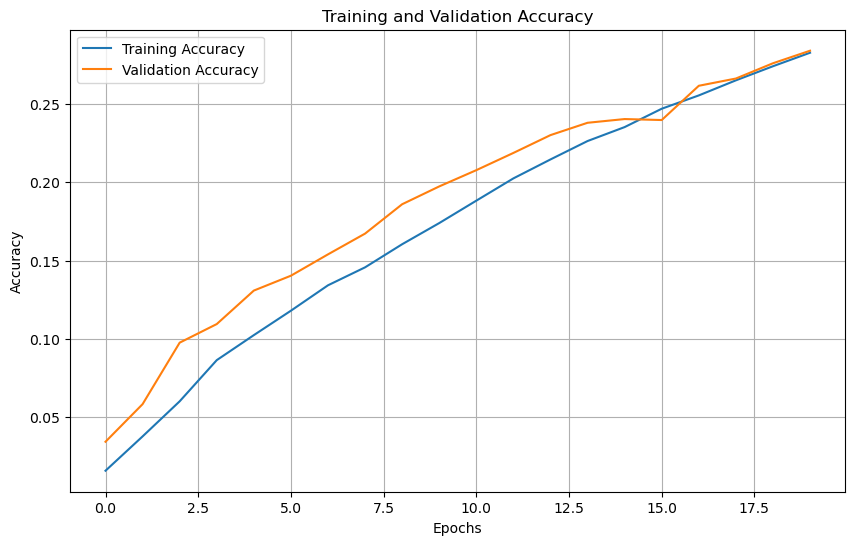

313/313 [==============================] - 1s 3ms/step


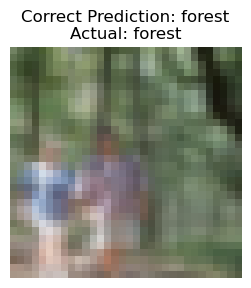

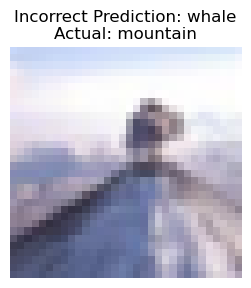

Top 5 Classification Probabilities:
whale: 0.1409
sea: 0.1359
mountain: 0.1089
bridge: 0.0848
cloud: 0.0469


In [10]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Predictions on the test set
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Find correctly and incorrectly classified examples
correct_indices = np.where(predicted_classes == true_classes)[0]
incorrect_indices = np.where(predicted_classes != true_classes)[0]

# Display one correctly classified image
plt.figure(figsize=(6, 3))
correct_image = correct_indices[0]
plt.imshow(x_test[correct_image])
plt.title(f'Correct Prediction: {class_names[predicted_classes[correct_image]]}\nActual: {class_names[true_classes[correct_image]]}')
plt.axis('off')
plt.show()

# Display one incorrectly classified image
plt.figure(figsize=(6, 3))
incorrect_image = incorrect_indices[0]
plt.imshow(x_test[incorrect_image])
plt.title(f'Incorrect Prediction: {class_names[predicted_classes[incorrect_image]]}\nActual: {class_names[true_classes[incorrect_image]]}')
plt.axis('off')
plt.show()

# Display top 5 classification probabilities for the incorrect image
sorted_probs = np.argsort(predictions[incorrect_image])[::-1][:5]
print("Top 5 Classification Probabilities:")
for i in sorted_probs:
    print(f'{class_names[i]}: {predictions[incorrect_image][i]:.4f}')

## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# Input Layers
# Conv2D used to detect features like edges, colours and textures in images
model.add(Conv2D
          (32, # filters: feature detectors to capture different patterns
          (3, 3), # kernal size: small filter size to detect low-level features
          activation='relu', # activiation is rectified linear unit - 
                             #introduce non-linearity 
          padding='same', # output size is the smae as input size
          input_shape=(32, 32, 3)))
# MaxPooling2D used to reduce spatial size of feature maps
model.add(MaxPooling2D(pool_size=(2, 2)))
## ADDED
model.add(BatchNormalization())

# Hidden Layers
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
## ADDED
model.add(BatchNormalization())

# Flatten Layer
# Converts 2D feature maps into 1D vector, Dense uses 1D as input
model.add(Flatten())
# Dense used to help the model learn complex patterns by combining all features 
# extracted from the previous layers
## UPDATED FILTERS FROM 128 TO 256
model.add(Dense(256, activation='relu'))
# Drop 30% of neurons during training, helps with overfitting and improves 
# generalization
model.add(Dropout(0.3))

# Output Layer
# 100 neurons represnt the classes in the CIFAR-100
# softmax activation ensures that the model outputs a probability distribution
# across the 100 classes
model.add(Dense(100, activation='softmax'))

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 16, 16, 32)       0         
 2D)                                                             
                                                                 
 batch_normalization (BatchN  (None, 16, 16, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                      

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

Epoch 1/20
1000/1000 [==============================] - 27s 26ms/step - loss: 4.1275 - accuracy: 0.0919 - val_loss: 3.7128 - val_accuracy: 0.1470
Epoch 2/20
1000/1000 [==============================] - 27s 27ms/step - loss: 3.5337 - accuracy: 0.1773 - val_loss: 3.3568 - val_accuracy: 0.2011
Epoch 3/20
1000/1000 [==============================] - 21s 21ms/step - loss: 3.1960 - accuracy: 0.2349 - val_loss: 3.1572 - val_accuracy: 0.2400
Epoch 4/20
1000/1000 [==============================] - 21s 21ms/step - loss: 2.9367 - accuracy: 0.2812 - val_loss: 3.1812 - val_accuracy: 0.2285
Epoch 5/20
1000/1000 [==============================] - 21s 21ms/step - loss: 2.7135 - accuracy: 0.3252 - val_loss: 2.8818 - val_accuracy: 0.2898
Epoch 6/20
1000/1000 [==============================] - 22s 22ms/step - loss: 2.5151 - accuracy: 0.3618 - val_loss: 2.8941 - val_accuracy: 0.2929
Epoch 7/20
1000/1000 [==============================] - 22s 22ms/step - loss: 2.3419 - accuracy: 0.3993 - val_loss: 2.7342 -

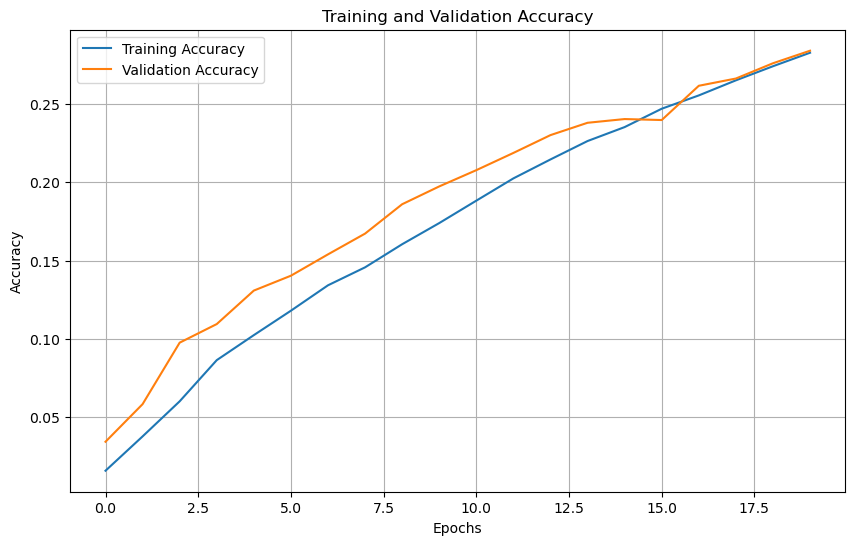

313/313 [==============================] - 1s 4ms/step


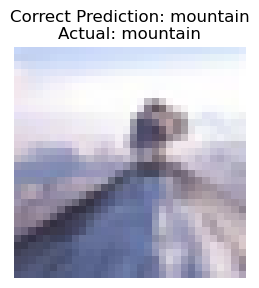

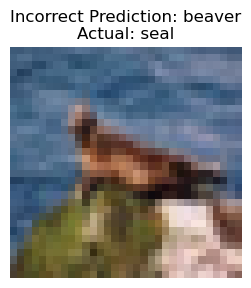

Top 5 Classification Probabilities:
beaver: 0.3352
seal: 0.1995
lobster: 0.1688
whale: 0.0716
otter: 0.0469


In [12]:
# Compile the model, definte the loss function, metrics and 
# evaluate the model based on the metrics
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

model.fit(
    x_train, # Training data
    y_train, # Training labels
    epochs=20, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

loss, accuracy = model.evaluate(x_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

y_test_labels = np.argmax(y_test, axis=1)
predicted_labels = np.argmax(model.predict(x_test), axis=1)

precision = precision_score(y_test_labels, predicted_labels, average='weighted')
print(f'Precision: {precision:.2f}')

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Predictions on the test set
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Find correctly and incorrectly classified examples
correct_indices = np.where(predicted_classes == true_classes)[0]
incorrect_indices = np.where(predicted_classes != true_classes)[0]

# Display one correctly classified image
plt.figure(figsize=(6, 3))
correct_image = correct_indices[0]
plt.imshow(x_test[correct_image])
plt.title(f'Correct Prediction: {class_names[predicted_classes[correct_image]]}\nActual: {class_names[true_classes[correct_image]]}')
plt.axis('off')
plt.show()

# Display one incorrectly classified image
plt.figure(figsize=(6, 3))
incorrect_image = incorrect_indices[0]
plt.imshow(x_test[incorrect_image])
plt.title(f'Incorrect Prediction: {class_names[predicted_classes[incorrect_image]]}\nActual: {class_names[true_classes[incorrect_image]]}')
plt.axis('off')
plt.show()

# Display top 5 classification probabilities for the incorrect image
sorted_probs = np.argsort(predictions[incorrect_image])[::-1][:5]
print("Top 5 Classification Probabilities:")
for i in sorted_probs:
    print(f'{class_names[i]}: {predictions[incorrect_image][i]:.4f}')

### Task 4c: Discussion of the results

- Briefly discuss the results. 
- Did the model's performance improve? 
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Answer
The model's performance improved from an accuracy of 29.30% to 37.95% after updates, indicating some positive progress. However, the accuracy remains relatively low, suggesting there is significant room for improvement. The initial low accuracy might be attributed to insufficient training or the model's architecture not being optimal for the given task.

The improvement in accuracy could be due to better model convergence after more epochs, but the model is still underperforming. This could be due to factors like the learning rate, data preprocessing, or the model's complexity.

There is definitely room for further improvement, especially since the accuracy is still far from optimal. Fine-tuning the learning rate, adding more layers or neurons to the model, or experimenting with more advanced architectures (like CNNs for image classification) could yield better results.

Other techniques to consider are data augmentation, regularization (e.g., dropout), batch normalization, or using different optimizers (e.g., Adam) to potentially speed up convergence and prevent overfitting. Trying pre-trained models could also help leverage existing feature extraction capabilities.


## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.